# Change Point Analysis and Statistical Modeling of Brent Oil Prices

## Business Understanding

Brent crude oil is one of the world's most important benchmark prices for crude oil and serves as a key indicator of global energy market conditions. Its price is highly influenced by geopolitical events, economic policies, supply-demand dynamics, production decisions by the Organization of the Petroleum Exporting Countries (OPEC), international sanctions, armed conflicts, and global economic crises.

Birhan Energies aims to provide data-driven insights that enable investors, policymakers, and energy companies to better understand how these events influence Brent oil prices. Detecting structural changes in historical price behavior allows stakeholders to evaluate market risks, anticipate future market conditions, and make more informed strategic decisions.

This project applies Bayesian Change Point Analysis to identify statistically significant structural breaks in Brent oil prices and investigate their potential association with major geopolitical and economic events. The findings will support investment decision-making, policy formulation, and operational planning within the energy sector.

## Project Objectives

The primary objective of this project is to analyze historical Brent crude oil prices and identify significant structural changes associated with major geopolitical and economic events.

Specific objectives include:

- Analyze historical Brent oil price trends and market behavior.
- Perform exploratory data analysis to understand price patterns.
- Investigate stationarity and volatility characteristics of the time series.
- Develop a Bayesian Change Point Detection model using PyMC.
- Identify statistically significant structural breaks in oil prices.
- Associate detected change points with historical geopolitical and economic events.
- Quantify the impact of major events on Brent oil prices.
- Develop an interactive dashboard for exploring analysis results.
- Communicate findings through professional reports and visualizations.

## Data Analysis Workflow

The project follows a structured data science workflow consisting of the following stages:

### 1. Data Collection

- Obtain historical Brent crude oil price data.
- Compile a structured dataset of major geopolitical and economic events affecting the oil market.

### 2. Data Preparation

- Load and inspect the datasets.
- Convert dates into appropriate datetime format.
- Check for missing values and inconsistencies.
- Prepare the data for statistical analysis.

### 3. Exploratory Data Analysis

- Visualize historical oil price movements.
- Analyze descriptive statistics.
- Identify long-term trends and volatility patterns.
- Explore price distributions and potential anomalies.

### 4. Time Series Analysis

- Assess stationarity using statistical tests.
- Analyze rolling statistics.
- Calculate log returns to stabilize variance.
- Investigate volatility clustering.

### 5. Bayesian Change Point Modeling

- Build a Bayesian Change Point Detection model using PyMC.
- Estimate structural break locations.
- Evaluate posterior distributions.
- Assess model convergence.

### 6. Event Association Analysis

- Compare detected change points with major historical events.
- Quantify price changes before and after significant events.
- Develop hypotheses explaining observed structural changes.

### 7. Result Communication

- Develop an interactive dashboard.
- Produce publication-quality visualizations.
- Prepare technical reports and business recommendations.

## Assumptions and Limitations

### Assumptions

- Historical Brent oil prices accurately represent global crude oil market behavior.
- Major geopolitical and economic events are the primary drivers of structural price changes.
- Bayesian Change Point Detection can effectively identify statistically significant shifts in the price series.
- Event dates collected from public sources reasonably approximate the timing of market impacts.

### Limitations

- Correlation does not imply causation. While change points may coincide with historical events, statistical association alone cannot prove that an event directly caused the observed price change.
- Financial markets often react before official announcements due to expectations and information leakage.
- Multiple events occurring within similar time periods may jointly influence oil prices, making attribution difficult.
- The analysis focuses primarily on Brent oil prices and does not explicitly incorporate macroeconomic variables such as GDP growth, inflation, exchange rates, or interest rates.
- Bayesian inference provides probabilistic estimates rather than deterministic conclusions.

## Communication Strategy

The findings of this analysis will be communicated to different stakeholder groups using formats tailored to their information needs.

| Stakeholder | Information Needed | Communication Format |
|-------------|-------------------|----------------------|
| Investors | Price trends, structural breaks, market risks, investment implications | Interactive dashboard, executive report, visualizations |
| Policymakers | Effects of geopolitical events and policy decisions on oil prices | Technical report, policy brief, dashboard |
| Energy Companies | Price forecasts, volatility analysis, operational risk assessment | Dashboard, technical documentation, presentations |
| Data Scientists & Analysts | Modeling methodology, Bayesian inference, reproducible analysis | Jupyter Notebook, GitHub repository, technical documentation |

The primary communication channels include:

- Interactive web dashboard for exploring historical prices and detected change points.
- Technical report documenting the methodology and findings.
- GitHub repository containing reproducible code and documentation.
- Professional visualizations illustrating structural changes and event impacts.

## Change Point Modeling Overview

Change point analysis is a statistical technique used to identify points in time where the underlying behavior of a time series changes significantly. These changes may occur due to external events such as geopolitical conflicts, economic crises, government policies, or major production decisions affecting the oil market.

In this project, Bayesian Change Point Detection is implemented using the PyMC probabilistic programming framework. The Bayesian approach estimates the posterior probability of potential change points rather than identifying a single deterministic breakpoint. This provides a probabilistic measure of uncertainty associated with each detected structural change.

The model assumes that Brent oil prices follow different statistical characteristics before and after a change point. By estimating these parameters, the analysis identifies periods where the average market behavior changes significantly.

The outputs of the Bayesian Change Point Model include:

- Estimated change point locations.
- Posterior probability distributions of change points.
- Estimated parameters before and after each structural break.
- Quantified changes in average Brent oil prices.
- Confidence in the detected structural changes.

These outputs provide valuable evidence for associating structural price shifts with major geopolitical and economic events.

## Expected Outputs

The expected outcomes of this project include:

- Cleaned and prepared Brent crude oil price dataset.
- Structured dataset of major geopolitical and economic events.
- Exploratory data analysis visualizations.
- Trend and volatility analysis.
- Stationarity test results.
- Bayesian Change Point Detection model.
- Posterior distributions of detected change points.
- Quantified impacts of major historical events on Brent oil prices.
- Interactive dashboard for stakeholder exploration.
- Technical report summarizing methodology, findings, limitations, and recommendations.

# Import Required Libraries

In [1]:
# =============================================================================
# Import Required Libraries
# =============================================================================

# Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Statistical analysis
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# Bayesian modeling
import pymc as pm
import arviz as az

# Date and warning handling
from datetime import datetime
import warnings

# Configure notebook settings
warnings.filterwarnings("ignore")

# Visualization style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("Libraries imported successfully.")

g++ not available, if using conda: `conda install gxx`


Libraries imported successfully.


# Load the Brent Oil Price Dataset

In [2]:
# =============================================================================
# Load Brent Oil Price Dataset
# =============================================================================

# Define dataset path
DATA_PATH = "../data/raw/BrentOilPrices.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

# Display first five rows
df.head()

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55
3,25-May-87,18.60
4,26-May-87,18.63


# Dataset Overview

This section explores the structure and quality of the Brent oil price dataset by examining its dimensions, data types, missing values, duplicate records, and summary statistics. These checks help identify potential preprocessing steps required before conducting exploratory data analysis and Bayesian change point modeling.

In [3]:
# =============================================================================
# Dataset Dimensions
# =============================================================================

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 9011
Number of Columns : 2


In [4]:
# =============================================================================
# Dataset Information
# =============================================================================

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   str    
 1   Price   9011 non-null   float64
dtypes: float64(1), str(1)
memory usage: 140.9 KB


In [5]:
# =============================================================================
# Missing Values
# =============================================================================

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Date     0
Price    0
dtype: int64


In [6]:
# =============================================================================
# Duplicate Records
# =============================================================================

duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

Duplicate Records: 0


In [7]:
# =============================================================================
# Summary Statistics
# =============================================================================

df.describe()

,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


## Initial Data Observations

The preliminary inspection of the Brent oil price dataset reveals that the dataset is complete and suitable for time series analysis.

Key observations include:

- The dataset contains **9,011 daily observations**.
- Two variables are available: **Date** and **Price**.
- The **Date** column is currently stored as a string and requires conversion to datetime format.
- The **Price** column is stored as a floating-point numerical variable.
- No missing values were detected.
- No duplicate records were found.
- Brent oil prices range from **USD 9.10** to **USD 143.95** per barrel, indicating substantial historical price variation.
- The wide standard deviation suggests considerable market volatility throughout the observation period.

These findings indicate that only minimal preprocessing is required before conducting exploratory data analysis and Bayesian change point modeling.

In [9]:
# =============================================================================
# Inspect Date Values
# =============================================================================

df["Date"].sample(20, random_state=42)

93      29-Sep-87
7272    19-Jan-16
447     16-Feb-89
6519    30-Jan-13
3898    26-Sep-02
          ...    
5431    25-Sep-08
653     06-Dec-89
730     28-Mar-90
5359    13-Jun-08
2412    06-Nov-96
Name: Date, Length: 20, dtype: str

In [10]:
# Find dates containing commas (likely the alternate format)
df[df["Date"].str.contains(",", na=False)].head(20)

,Date,Price
8360,"Apr 22, 2020",13.77
8361,"Apr 23, 2020",15.06
8362,"Apr 24, 2020",15.87
8363,"Apr 27, 2020",15.17
8364,"Apr 28, 2020",15.60
...,...,...
8375,"May 14, 2020",29.87
8376,"May 15, 2020",30.95
8377,"May 18, 2020",33.30
8378,"May 19, 2020",33.06


In [11]:
# =============================================================================
# Convert Date Column
# =============================================================================

df["Date"] = pd.to_datetime(df["Date"], format="mixed")

# Sort chronologically
df = df.sort_values("Date")

# Reset index
df.reset_index(drop=True, inplace=True)

# Set Date as index
df.set_index("Date", inplace=True)

# Verify
df.head()

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


In [12]:
print(f"Start Date : {df.index.min()}")
print(f"End Date   : {df.index.max()}")
print(f"Total Observations : {len(df)}")

Start Date : 1987-05-20 00:00:00
End Date   : 2022-11-14 00:00:00
Total Observations : 9011


## Date Conversion

The `Date` column contains mixed string formats. Earlier observations use the format `DD-Mon-YY` (e.g., `20-May-87`), while later observations use the format `Mon DD, YYYY` (e.g., `Apr 22, 2020`).

To ensure all observations are parsed correctly, Pandas' mixed-format datetime parser is used before sorting the dataset chronologically and setting the `Date` column as the index.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the historical behavior of Brent crude oil prices before applying Bayesian Change Point Detection. This phase focuses on identifying long-term trends, price distributions, volatility patterns, and statistical properties of the time series.

The insights gained from EDA help determine whether structural changes exist in the data and guide the selection of appropriate statistical models.

## Historical Brent Oil Price Trend

Visualizing the historical Brent crude oil prices provides an overview of long-term market behavior. The time series plot highlights periods of sustained growth, sharp declines, and increased volatility that may correspond to major geopolitical or economic events.

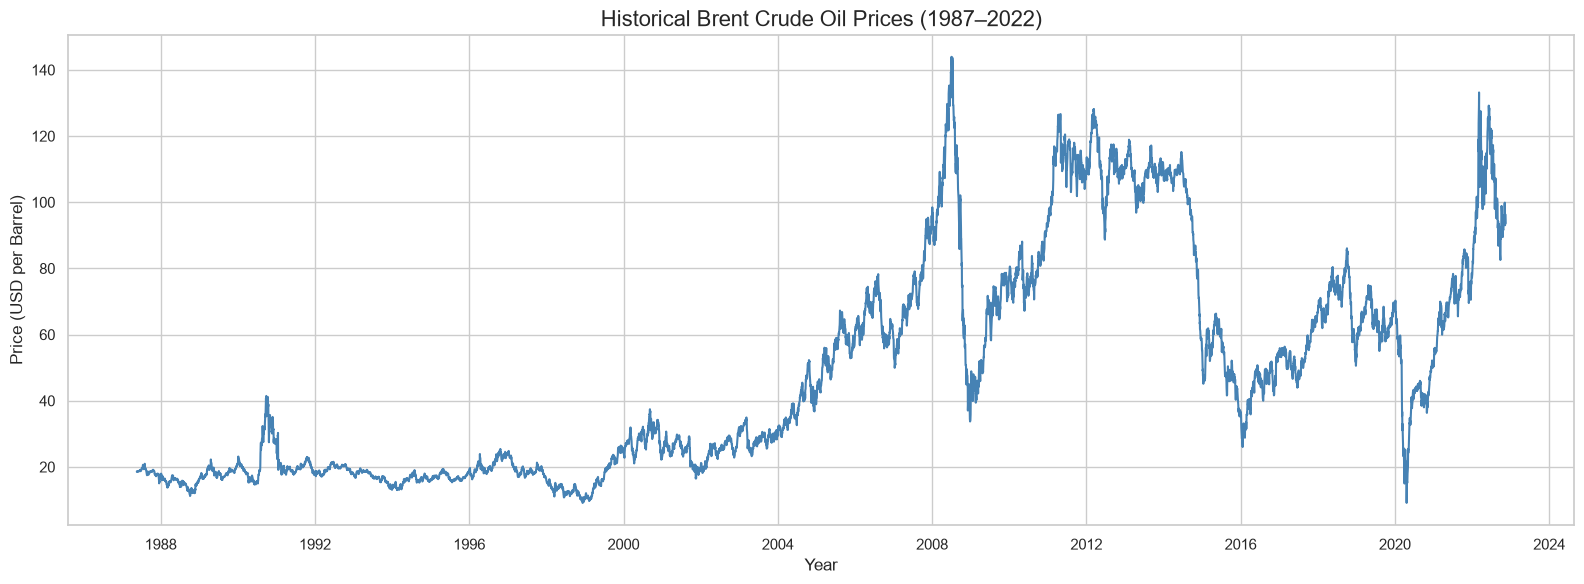

In [13]:
# =============================================================================
# Historical Brent Oil Price Trend
# =============================================================================

plt.figure(figsize=(16, 6))

plt.plot(
    df.index,
    df["Price"],
    linewidth=1.5,
    color="steelblue"
)

plt.title("Historical Brent Crude Oil Prices (1987–2022)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Price (USD per Barrel)", fontsize=12)

plt.grid(True)

plt.tight_layout()

plt.show()

### Interpretation

The historical Brent crude oil price series exhibits substantial long-term fluctuations, reflecting the sensitivity of the global oil market to geopolitical events, economic conditions, and changes in supply and demand. Rather than following a stable trend, the series consists of multiple periods of rapid growth and sharp declines, indicating the presence of structural changes over time.

Several major historical events are visually associated with significant price movements. Prices remained relatively low and stable throughout the late 1980s and 1990s, with temporary increases during the Gulf War. A prolonged upward trend began in the early 2000s, culminating in a peak of over USD 140 per barrel during the 2008 commodity boom before collapsing during the global financial crisis. Additional periods of heightened volatility are observed during the 2014–2016 oil market oversupply, the COVID-19 pandemic in 2020, and the Russia–Ukraine conflict in 2022.

These pronounced shifts suggest that the underlying statistical properties of the series change over time, supporting the use of Bayesian Change Point Detection to identify structural breaks and relate them to major geopolitical and economic events.

## Distribution of Brent Oil Prices

The distribution of Brent oil prices provides insight into the frequency of different price levels observed over the study period. This helps identify skewness, potential outliers, and whether prices are concentrated around specific ranges.

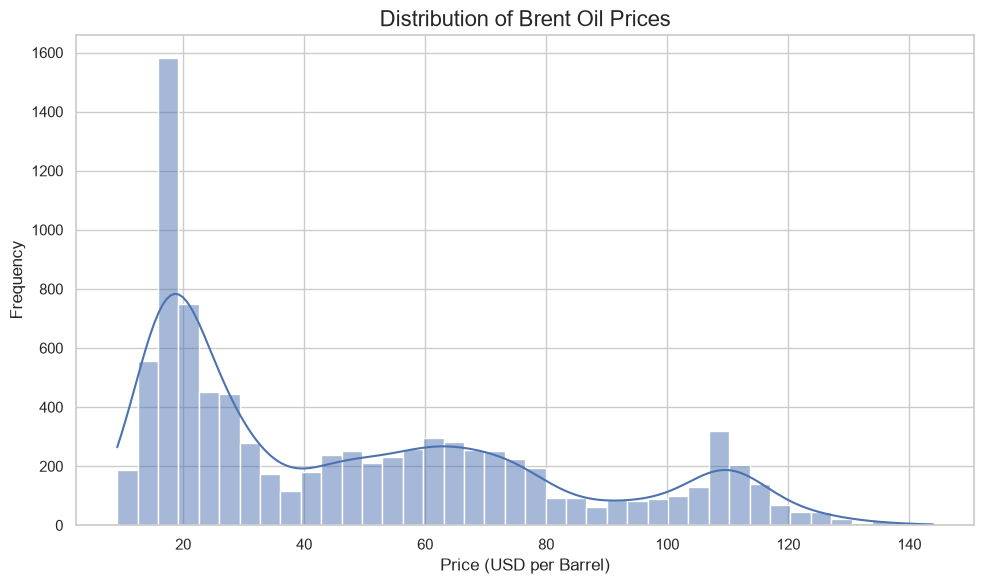

In [14]:
# =============================================================================
# Distribution of Brent Oil Prices
# =============================================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Brent Oil Prices", fontsize=16)
plt.xlabel("Price (USD per Barrel)")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Interpretation

The distribution of Brent crude oil prices is clearly non-normal and exhibits multiple peaks, indicating that prices have historically clustered around different market regimes rather than a single equilibrium level. The highest concentration of observations occurs at lower price levels, reflecting the prolonged period of relatively stable prices during the late 1980s and 1990s.

Additional peaks appear at medium and high price ranges, corresponding to periods of sustained economic expansion, supply constraints, and geopolitical uncertainty. This multimodal distribution suggests that the oil market transitions between distinct pricing environments driven by changing global conditions.

The observed distribution highlights the complexity of Brent oil price dynamics and indicates that models capable of capturing structural changes and regime shifts are more appropriate than those assuming a single stationary distribution.

## Boxplot of Brent Oil Prices

A boxplot summarizes the distribution of Brent oil prices by highlighting the median, interquartile range, and potential outliers. This visualization provides a concise view of price variability and extreme observations.

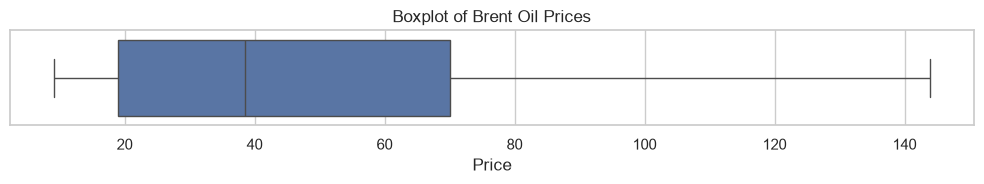

In [15]:
# =============================================================================
# Boxplot
# =============================================================================

plt.figure(figsize=(10, 2))

sns.boxplot(
    x=df["Price"]
)

plt.title("Boxplot of Brent Oil Prices")

plt.tight_layout()

plt.show()

### Interpretation

The boxplot summarizes the variability of Brent crude oil prices over the study period. The median price is substantially lower than the maximum observed value, while the upper whisker extends considerably farther than the lower whisker, indicating a positively skewed distribution.

The wide interquartile range reflects considerable variability in oil prices across different market conditions. Extreme price increases, particularly during periods of geopolitical instability and global supply disruptions, contribute to the long upper tail of the distribution.

Overall, the boxplot confirms that Brent oil prices are highly variable and asymmetric, emphasizing the influence of extraordinary market events on long-term price behavior.

## Rolling Statistics

Rolling statistics smooth short-term fluctuations and reveal long-term changes in the average price and variability of Brent crude oil. A 30-day rolling window is used to visualize local trends and volatility over time.

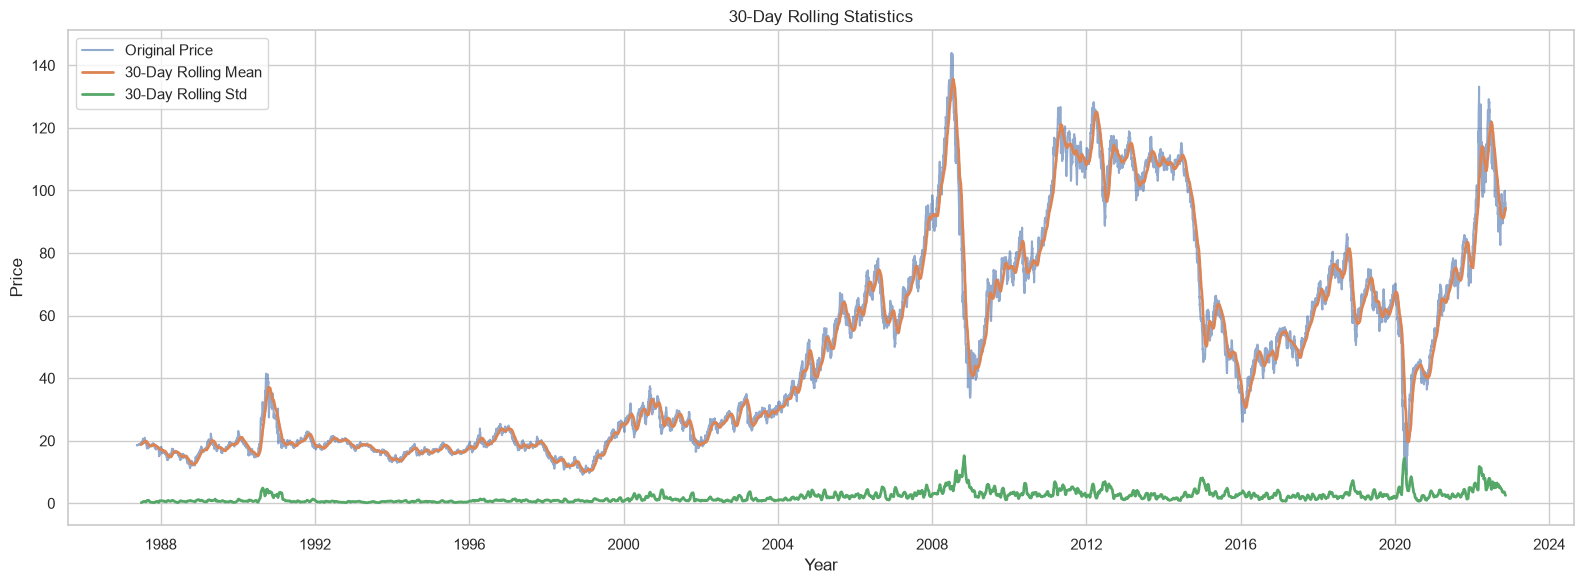

In [16]:
# =============================================================================
# Rolling Statistics
# =============================================================================

rolling_mean = df["Price"].rolling(window=30).mean()

rolling_std = df["Price"].rolling(window=30).std()

plt.figure(figsize=(16, 6))

plt.plot(df.index, df["Price"], label="Original Price", alpha=0.6)

plt.plot(df.index, rolling_mean, label="30-Day Rolling Mean", linewidth=2)

plt.plot(df.index, rolling_std, label="30-Day Rolling Std", linewidth=2)

plt.title("30-Day Rolling Statistics")

plt.xlabel("Year")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

### Interpretation

The 30-day rolling mean reveals that the average Brent crude oil price changes substantially over time, indicating the presence of long-term trends rather than a constant mean. Similarly, the rolling standard deviation varies considerably throughout the observation period, with pronounced spikes during periods of market disruption.

Notable increases in volatility coincide with major geopolitical and economic events, including the Gulf War, the 2008 global financial crisis, the 2014–2016 oil price collapse, the COVID-19 pandemic, and the Russia–Ukraine conflict. These periods are characterized by rapid price fluctuations and elevated market uncertainty.

The changing rolling mean and rolling standard deviation indicate that the Brent oil price series is non-stationary, as both its central tendency and variability evolve over time. This observation motivates the application of formal stationarity tests and supports the use of Bayesian Change Point Detection to identify structural shifts in the series.

## Stationarity Analysis

Stationarity testing is an important step in time series analysis because many statistical models assume that the underlying data has constant statistical properties over time.

A stationary time series has:
- Constant mean
- Constant variance
- Time-independent autocorrelation structure

The Augmented Dickey-Fuller (ADF) test is applied to determine whether the Brent oil price series is stationary.

The hypotheses are:

- Null hypothesis (H0): The time series contains a unit root and is non-stationary.
- Alternative hypothesis (H1): The time series is stationary.

In [17]:
# =============================================================================
# Augmented Dickey-Fuller Stationarity Test
# =============================================================================

adf_result = adfuller(df["Price"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.993856011392467
p-value: 0.2892735048934032

Critical Values:
1%: -3.4310783342658615
5%: -2.861861876398633
10%: -2.566941329781918


In [18]:
# Calculate log returns

df["Log_Return"] = np.log(
    df["Price"] / df["Price"].shift(1)
)

df["Log_Return"].dropna().head()

Date
1987-05-21   -0.009709
1987-05-22    0.005405
1987-05-25    0.002692
1987-05-26    0.001612
1987-05-27   -0.001612
Name: Log_Return, dtype: float64

In [19]:
returns_adf = adfuller(
    df["Log_Return"].dropna()
)

print("ADF Statistic:", returns_adf[0])
print("p-value:", returns_adf[1])

ADF Statistic: -16.42711349448569
p-value: 2.4985801611439457e-29


## Interpretation of Stationarity Test Results

The Augmented Dickey-Fuller (ADF) test was applied to both the original Brent crude oil price series and the transformed log return series.

For the Brent oil price series, the ADF statistic was -1.99 with a p-value of 0.289. Since the p-value is greater than the 5% significance level, the null hypothesis of a unit root cannot be rejected. Therefore, the original Brent price series is considered non-stationary.

This result is consistent with the behavior observed during exploratory analysis, where the rolling mean and volatility changed substantially over time. Long-term trends, inflation effects, supply disruptions, and geopolitical events cause the statistical properties of oil prices to vary across different market regimes.

After transforming the prices into logarithmic returns, the ADF statistic decreased significantly to -16.43, indicating strong evidence against the presence of a unit root. Therefore, log returns are stationary and provide a more stable representation of short-term price movements.

These findings influence the modeling strategy. Since Brent prices are non-stationary, structural change analysis focuses on identifying regime shifts in the price behavior, while transformed returns can be used for statistical modeling of volatility and market dynamics.

# Change Point Analysis Methodology

## Purpose of Change Point Models

Change point analysis is a statistical approach used to identify points in a time series where the underlying data-generating process changes significantly. These changes are known as **structural breaks**.

In financial and energy markets, prices are influenced by changing economic conditions, geopolitical events, supply disruptions, demand shocks, and policy decisions. As a result, the behavior of commodity prices is rarely constant over long periods. The average price level, volatility, and statistical relationships may change when the market enters a new regime.

For Brent crude oil prices, change point analysis helps identify periods where the characteristics of the oil market shifted significantly. Examples include sudden supply disruptions, economic recessions, production policy changes by OPEC, and global energy crises.

---

## Structural Breaks in Brent Oil Prices

A structural break represents a significant change in the statistical properties of a time series. In the context of Brent oil prices, structural breaks may appear as:

- A sudden increase or decrease in average oil prices.
- A change in price volatility.
- A transition between different market regimes.
- A permanent shift in supply-demand dynamics.

For example:

- The 2008 Global Financial Crisis caused a major decline in oil prices due to reduced global demand.
- The 2014 OPEC production decision contributed to a prolonged period of lower oil prices.
- The 2020 COVID-19 pandemic created an unprecedented demand shock and extreme volatility.
- The 2022 Russia-Ukraine conflict increased supply uncertainty and caused significant price movements.

Change point models help detect these transitions statistically rather than relying only on visual inspection.

---

## Bayesian Change Point Model Approach

This project applies Bayesian Change Point Detection using the PyMC probabilistic programming framework.

Unlike traditional methods that provide a single estimated breakpoint, Bayesian models estimate the probability distribution of possible change points. This allows uncertainty around detected structural breaks to be quantified.

The model assumes that Brent oil prices follow different statistical regimes before and after a change point. Each regime may have different parameters, such as:

- Mean price level.
- Variance or volatility.
- Distribution characteristics.

The Bayesian approach estimates posterior distributions for these parameters and identifies the most probable locations where the market behavior changed.

---

## Expected Outputs of Change Point Analysis

The change point model is expected to produce:

1. **Detected Change Point Dates**
   
   - Dates where statistically significant structural changes occurred.

2. **Posterior Probability Distributions**
   
   - Probability estimates showing confidence in detected change points.

3. **Regime Parameters**
   
   - Estimated market characteristics before and after each change point.

4. **Price Impact Analysis**
   
   - Quantification of how average prices changed between different regimes.

5. **Event Association Analysis**
   
   - Comparison between detected change points and historical events such as wars, financial crises, OPEC decisions, and economic shocks.

---

## Limitations of Change Point Analysis

Although change point models are useful for identifying structural changes, they have important limitations:

- A detected change point does not prove that a specific event caused the price change.
- Multiple events may occur around the same period, making attribution difficult.
- The model identifies statistical changes but does not automatically explain the economic mechanism behind them.
- Results depend on model assumptions, selected distributions, and parameter choices.
- Market participants may react before an official event date due to expectations and information availability.

Therefore, detected change points should be interpreted as evidence of market regime changes rather than direct proof of causal relationships.

In [21]:
# =============================================================================
# Load Event Dataset
# =============================================================================

events = pd.read_csv("../data/events/brent_oil_events.csv")

events["date"] = pd.to_datetime(events["date"])

events.head()

,date,event,category,description
0,1990-08-02,Gulf War Begins,Geopolitical,Iraq invaded Kuwait causing concerns about Mid...
1,1991-01-17,Gulf War Military Intervention,Geopolitical,Military operations in the Gulf region increas...
2,1997-07-01,Asian Financial Crisis,Economic,Financial instability reduced economic activit...
3,1998-03-30,OPEC Production Agreement,OPEC,OPEC members agreed on production adjustments ...
4,2003-03-20,Iraq War Begins,Geopolitical,Conflict in Iraq increased concerns about disr...


In [22]:
print("Event Start:", events["date"].min())
print("Event End:", events["date"].max())

Event Start: 1990-08-02 00:00:00
Event End: 2022-10-05 00:00:00


In [23]:
# Check whether event dates exist in Brent trading dates

matched_dates = events[
    events["date"].isin(df.index)
]

print(
    f"Events matching Brent trading dates: {len(matched_dates)} / {len(events)}"
)

Events matching Brent trading dates: 13 / 15


## Event Dataset Validation

The compiled Brent oil event dataset contains 15 major geopolitical, economic, and OPEC-related events occurring between 1990 and 2022.

The event dates were compared with the Brent oil price dataset to verify temporal consistency. Out of the 15 identified events, 13 dates directly matched available Brent trading observations.

The remaining events did not have exact date matches because financial markets operate only on trading days and some historical events occurred during weekends or non-trading periods. These events remain relevant because their market impact may appear before or after the official event date.

Therefore, event association during change point analysis will not rely on exact date matching. Instead, detected structural breaks will be compared against historical events within an appropriate time window.

# Task 1 Summary and Next Steps

## Summary of Initial Analysis

This phase established the foundation for analyzing Brent crude oil price behavior and preparing the dataset for structural change detection.

The initial analysis included:

- Loading and validating the historical Brent crude oil price dataset.
- Performing data quality checks, including missing value and duplicate detection.
- Preparing the time series by converting dates and organizing observations chronologically.
- Conducting exploratory data analysis to understand long-term price trends, distributions, and volatility patterns.
- Performing stationarity testing using the Augmented Dickey-Fuller (ADF) test.
- Compiling and validating a structured dataset of major geopolitical, economic, and OPEC-related events.

The exploratory analysis revealed that Brent oil prices experience significant fluctuations and transition between different market conditions. Major periods of increased volatility were observed around events such as geopolitical conflicts, financial crises, supply disruptions, and global economic shocks.

The ADF test confirmed that the Brent price series is non-stationary, while log returns demonstrate stationary behavior. This indicates that oil prices are influenced by changing market regimes and supports the application of structural break detection methods.

---

## Key Insights

The main findings from Task 1 include:

- Brent crude oil prices do not follow a constant trend and exhibit multiple market regimes.
- Price volatility changes significantly over time, particularly during major global events.
- Historical events often coincide with periods of significant price movements; however, temporal association does not prove causation.
- The presence of structural changes motivates the use of Bayesian Change Point Analysis to identify statistically significant regime shifts.

---

## Next Steps

The next stage of the project will focus on implementing Bayesian Change Point Detection using PyMC.

The upcoming analysis will:

- Develop a probabilistic change point model for Brent oil prices.
- Estimate posterior distributions of possible structural breaks.
- Identify significant market regime changes.
- Compare detected change points with historical geopolitical and economic events.
- Analyze changes in price behavior before and after detected structural breaks.

The results will provide deeper insights into how global events are associated with changes in Brent crude oil market behavior.